# Age Class Detection System Using CNN and Transfer Learning with ResNet18

In [1]:
# Problem Statement:
# The goal of this project is to build an automated Age Detection system
# using Convolutional Neural Networks (CNN) and transfer learning.
# The dataset contains face images organized into age group categories
# (e.g., '18-20', '21-30', etc.), separated into training and testing sets.

# Steps involved:
# 1. Preprocess input face images by resizing, normalizing, and applying
#    data augmentation techniques (random flips, rotations, color jitter, etc.).
# 2. Load dataset using PyTorch's ImageFolder and DataLoader utilities.
# 3. Use a pretrained ResNet18 model as the backbone and fine-tune only
#    the last convolutional block and fully connected layer for classification.
# 4. Train the model using cross-entropy loss and Adam optimizer.
# 5. Evaluate the model on the test dataset by generating predictions.
# 6. Report classification performance using accuracy and other metrics
#    (via classification report).


# Objective:
# To accurately classify a given face image into one of the predefined
# age group categories, thereby enabling age group recognition from facial features.

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Import Required Libraries

In [3]:
# Import Required Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report

### Set Device (CPU/GPU)

In [4]:
# Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using", device)

Using cuda


In [5]:
# train and test dataset paths
train_path = "/content/drive/MyDrive/Datasets/Age_Detection-Face_Recognition_Dataset/train"
test_path = "/content/drive/MyDrive/Datasets/Age_Detection-Face_Recognition_Dataset/test"

In [6]:
from PIL import Image

### Image Transformations

In [7]:
# Common image size & batch
img_size = 224    # We resize all images to 224x224 pixels. This is a common size required by popular pretrained models (like ResNet).


mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]
# define transforms
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),      # Flip left-right
    transforms.RandomVerticalFlip(p=0.2),        # Flip up-down (sometimes useful)
    transforms.RandomRotation(25),               # Rotate image within ±25°
    transforms.ColorJitter(                      # Change brightness, contrast, saturation
        brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1
    ),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),  # Random zoom & crop
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])
test_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean, std=std)
])

### Load the data from the folders

In [8]:
# Load training images from folders.
# Automatically assigns labels based on folder names (e.g., '18-20', '21-30', etc.).
# Applies the train_transforms (resize, flip, normalize, etc.) to each image.
full_train_data = datasets.ImageFolder(train_path, transform=train_transforms)
test_data  = datasets.ImageFolder(test_path,  transform=test_transforms)

In [9]:
len(full_train_data), len(test_data)

(125, 25)

### Split Train-Validation data

In [10]:
# Validation split (e.g., 80% train, 20% val)
train_size = int(0.8 * len(full_train_data))
val_size = len(full_train_data) - train_size
train_data, val_data = random_split(full_train_data, [train_size, val_size])

In [11]:
len(train_data), len(val_data), len(test_data)

(100, 25, 25)

### Create Data Loaders

In [12]:
# Data loaders
train_loader = DataLoader(train_data, batch_size=16, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data, batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2)

In [13]:
# Class names
class_names = full_train_data.classes
print("Classes:", class_names)

Classes: ['18-20', '21-30', '31-40', '41-50', '51-60']


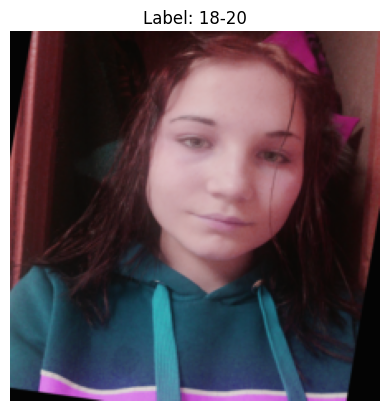

In [14]:
# Show sample image with label
x, y = full_train_data[10]
img = x.numpy()
img = np.transpose(img, (1,2,0))
# unnormalize for visualization
img = std * img + mean
img = np.clip(img, 0, 1)
plt.imshow(img)
plt.title(f"Label: {class_names[y]}")
plt.axis("off")
plt.show()

### Building a ResNet Model

In [15]:
model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 157MB/s]


In [16]:
# Unfreeze last block (layer4) + FC
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:   # check if parameter belongs to last block or fc
        param.requires_grad = True         # unfreeze (make trainable)
    else:
        param.requires_grad = False        # freeze (do not update)

In [17]:
# Check the final fully connected (fc) layer
model.fc

Linear(in_features=512, out_features=1000, bias=True)

In [18]:
# Replace the final fc layer to match OUR dataset (example: 5 age groups)
num_ftrs = model.fc.in_features   # number of input features = 512
model.fc = nn.Linear(num_ftrs, len(class_names)) # new layer: 512 → 5 classes
model = model.to(device)

In [19]:
# Verify the new fc layer
print(model.fc)

Linear(in_features=512, out_features=5, bias=True)


In [20]:
criterion=nn.CrossEntropyLoss().to(device) # For classification tasks we usually use CrossEntropyLoss
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
# filter(lambda p: p.requires_grad, model.parameters()) ---> goes through all model parameters and keeps only the ones that are trainable.

### Training and Validation Loop

In [21]:
from tqdm import tqdm   # tqdm is used to show progress bars during training

n_epochs = 20           # number of epochs to train the model
train_losses = []       # list to store average training loss per epoch
val_losses = []         # list to store average validation loss per epoch

for epoch in range(n_epochs):   # loop over epochs
    # ----- Training -----
    model.train()               # set model to training mode (activates dropout, batchnorm, etc.)
    total_train_loss = 0        # variable to accumulate training loss for this epoch

    # loop over all training batches
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs} [Training]"):
        images, labels = images.to(device), labels.to(device)  # move batch to GPU/CPU

        optimizer.zero_grad()    # reset gradients from previous iteration
        outputs = model(images)  # forward pass: model predictions
        loss = criterion(outputs, labels)  # compute loss between predictions and labels
        loss.backward()          # backward pass: compute gradients
        optimizer.step()         # update weights using optimizer

        total_train_loss += loss.item()  # accumulate training loss for this epoch

    # compute average training loss for the epoch
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)  # save it for plotting later

    # ----- Validation -----
    model.eval()                # set model to evaluation mode (deactivates dropout, fixes batchnorm)
    total_val_loss = 0          # variable to accumulate validation loss for this epoch

    with torch.no_grad():       # disable gradient computation during validation
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{n_epochs} [Validation]"):
            images, labels = images.to(device), labels.to(device)  # move batch to device
            outputs = model(images)   # forward pass
            loss = criterion(outputs, labels)  # compute validation loss
            total_val_loss += loss.item()      # accumulate validation loss

    # compute average validation loss for the epoch
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)   # save it for plotting later

    print(f"Epoch : {epoch+1} | " f"Train Loss : {avg_train_loss:.4f} | " f"Val Loss : {avg_val_loss:.4f}")


Epoch 1/20 [Validation]: 100%|██████████| 2/2 [00:28<00:00, 14.33s/it]


Epoch : 1 | Train Loss : 1.8464 | Val Loss : 2.9741


Epoch 2/20 [Validation]: 100%|██████████| 2/2 [00:23<00:00, 11.67s/it]


Epoch : 2 | Train Loss : 1.1247 | Val Loss : 2.5471


Epoch 3/20 [Validation]: 100%|██████████| 2/2 [00:25<00:00, 12.96s/it]


...

Epoch : 18 | Train Loss : 0.3405 | Val Loss : 3.3901


Epoch 19/20 [Validation]: 100%|██████████| 2/2 [00:26<00:00, 13.11s/it]


Epoch : 19 | Train Loss : 0.2868 | Val Loss : 2.8130


Epoch 20/20 [Validation]: 100%|██████████| 2/2 [00:27<00:00, 13.69s/it]

Epoch : 20 | Train Loss : 0.2165 | Val Loss : 2.8241


### Plot Training and Validation Loss

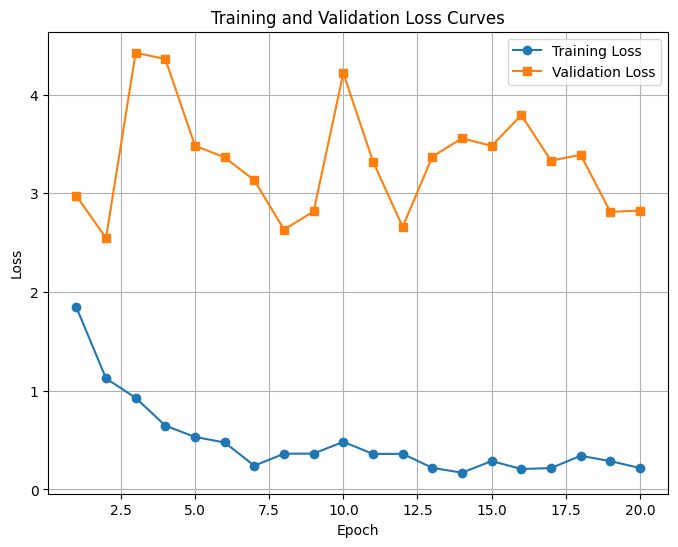

In [22]:
# Plot training & validation loss curves
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Validation Loss', marker='s')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

### Evaluate Model on Test Data

In [23]:
model.eval()

y_preds = []
y_acts = []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        # move to CPU before converting to numpy
        np_out = outputs.detach().cpu().numpy()
        y_pred = np_out.argmax(1)

        y_preds.extend(list(y_pred))
        y_acts.extend(list(labels.cpu().numpy()))


100%|██████████| 1/1 [00:12<00:00, 12.70s/it]


In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_acts,y_preds))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.25      0.20      0.22         5
           2       0.12      0.20      0.15         5
           3       0.00      0.00      0.00         5
           4       0.44      0.80      0.57         5

    accuracy                           0.24        25
   macro avg       0.16      0.24      0.19        25
weighted avg       0.16      0.24      0.19        25



In [ ]:
# 1. Dataset size is too small
#    - Only 125 training images is very limited for deep models like ResNet.
#    - Deep models usually require thousands of images per class.
#    - Small dataset → model memorizes training data but fails on validation/test (overfitting).

# 2. Validation & test sets are tiny (25 images each)
#    - With so few samples, one misclassification changes accuracy drastically.
#    - Reported metrics may look unstable or inconsistent.

# 3. Validation loss stays high (doesn’t follow training loss)
#    - Training loss decreases well → model is learning training data.
#    - Validation loss fluctuates and remains high → poor generalization.